AI Job-Match Analyzer

In [57]:
import numpy as np 
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [58]:
df = pd.read_csv('resume_dataset.csv')
df.head()

,id,category,skills,education,experience,text,html
0,21614256,ADVOCATE,"Word programs (including Excel and Access), EP...","Boston University, Master of Public Health, Ep...","Bilingual Domestic Violence Advocate, Intern, ...",BILINGUAL DOMESTIC VIOLENCE ADVOCATE ...,"<div class=""fontsize fontface vmargins hmargin..."
1,97405769,ADVOCATE,"Superb sales professional, Store planning and ...","William Penn Vo-tech, General-Business, High S...","Customer Service Advocate, Sales Manager, Sale...",CUSTOMER SERVICE ADVOCATE Summa...,"<div class=""fontsize fontface vmargins hmargin..."
2,95970987,ADVOCATE,"Domestic Violence, Sexual Abuse, Rape, Prostit...","Boricua College, Human Services Psychology and...","Clinical Service Advocate, Women's Empowerment...",CLINICAL SERVICE ADVOCATE Profe...,"<div class=""fontsize fontface vmargins hmargin..."
3,17021141,ADVOCATE,"Accounting, Cashiering, Coaching, Computer tra...",University of Phoenix - Master of Business Adm...,"PH Inpatient/Financial Advocate Supervisor, PH...",PH INPATIENT/FINANCIAL ADVOCATE SUPER...,"<div class=""fontsize fontface vmargins hmargin..."
4,15337481,ADVOCATE,"Microsoft Suite Proficiency, RightFax Ventura,...","El Centro Community College, Health Administra...","Customer Service Advocate, Collection Speciali...",CUSTOMER SERVICE ADVOCATE Summa...,"<div class=""fontsize fontface vmargins hmargin..."


In [59]:
df.shape

(2257, 7)

In [60]:
df.columns

Index(['id', 'category', 'skills', 'education', 'experience', 'text', 'html'], dtype='str')

In [61]:
df.isnull().sum()

id            0
category      0
skills        0
education     0
experience    0
text          0
html          0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df.drop(columns=['html'], inplace= True)

In [64]:
df.drop(columns=['id'], inplace= True)

In [65]:
df.head(3)

,category,skills,education,experience,text
0,ADVOCATE,"Word programs (including Excel and Access), EP...","Boston University, Master of Public Health, Ep...","Bilingual Domestic Violence Advocate, Intern, ...",BILINGUAL DOMESTIC VIOLENCE ADVOCATE ...
1,ADVOCATE,"Superb sales professional, Store planning and ...","William Penn Vo-tech, General-Business, High S...","Customer Service Advocate, Sales Manager, Sale...",CUSTOMER SERVICE ADVOCATE Summa...
2,ADVOCATE,"Domestic Violence, Sexual Abuse, Rape, Prostit...","Boricua College, Human Services Psychology and...","Clinical Service Advocate, Women's Empowerment...",CLINICAL SERVICE ADVOCATE Profe...


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2257 entries, 0 to 2256
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   category    2257 non-null   str  
 1   skills      2257 non-null   str  
 2   education   2257 non-null   str  
 3   experience  2257 non-null   str  
 4   text        2257 non-null   str  
dtypes: str(5)
memory usage: 15.0 MB


In [67]:
df['category'].value_counts()

category
BUSINESS-DEVELOPMENT      118
FINANCE                   118
ACCOUNTANT                117
FITNESS                   116
AVIATION                  116
HEALTHCARE                115
CONSULTANT                115
SALES                     114
CHEF                      114
ENGINEERING               114
BANKING                   114
HR                        112
PUBLIC-RELATIONS          110
CONSTRUCTION              109
DESIGNER                  105
ARTS                      102
APPAREL                    97
DIGITAL-MEDIA              93
INFORMATION-TECHNOLOGY     82
AGRICULTURE                62
ADVOCATE                   57
AUTOMOBILE                 36
BPO                        21
Name: count, dtype: int64

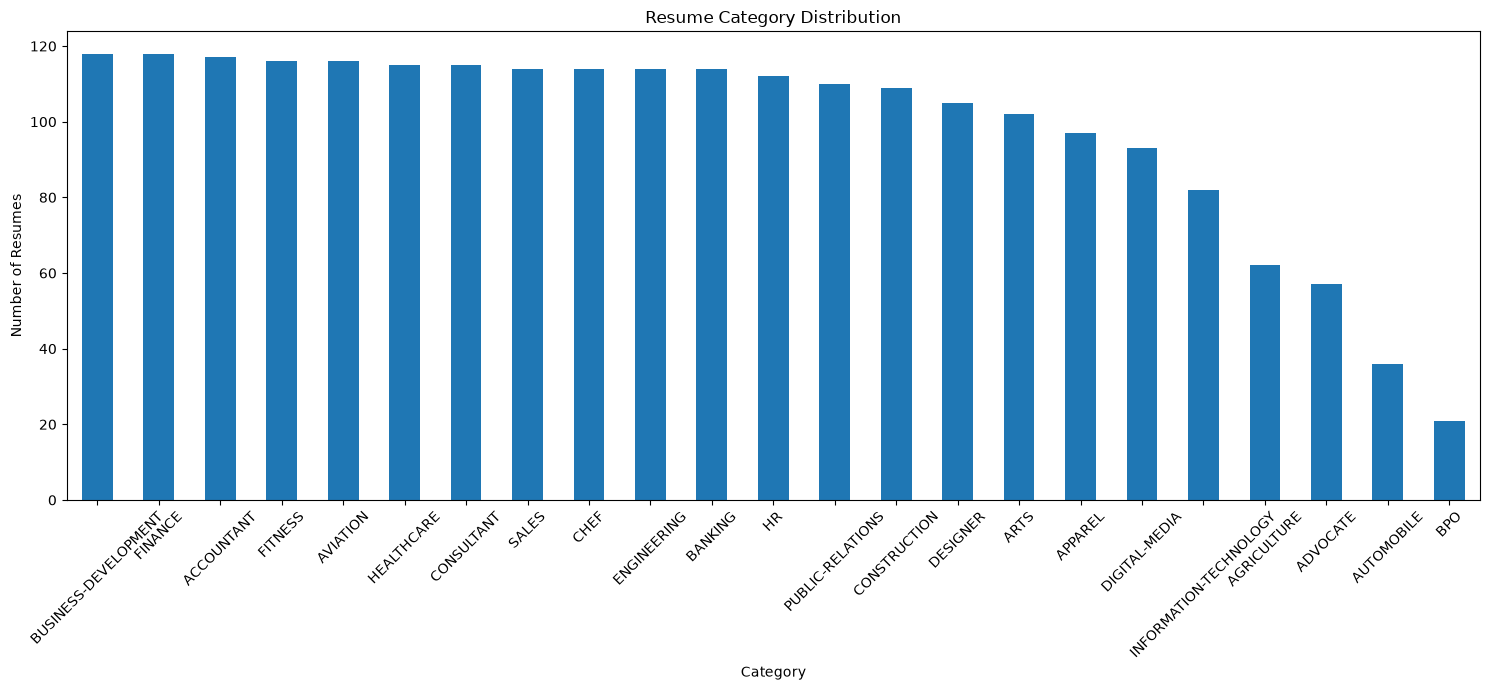

In [68]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar', figsize=(15, 7))

plt.xlabel('Category')
plt.ylabel('Number of Resumes')
plt.title('Resume Category Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
print(df['text'].iloc[0])

         BILINGUAL DOMESTIC VIOLENCE ADVOCATE         Skills        Word programs (including Excel and Access), EPIC and other 
electronic medical records, and the database Efforts to Outcome (ETO). Working knowledge     
of SAS and R.            Experience      Bilingual Domestic Violence Advocate     Sep 2015   to   Nov 2016      Company Name   －   City  ,   State     Provided advocacy services appropriate to client needs to a caseload of approximately 30 clients, through in person and/or phone contact.  Advocacy services included crisis intervention, risk assessment, safety planning, supportive counseling, and assistance in accessing community resources.  Covered on-call service one to two times a week, on average.  On-call service entailed serving as the first responder for intimate partner violence referrals from the hospital, as well as self-referrals from the community.  Documented in Passageway database (ETO) and EPIC as appropriate.  Utilized various clinical strategies in wor

In [70]:
df['text_length'] = df['text'].str.len()

df['text_length'].describe()

count     2257.000000
mean      6306.289322
std       2677.020523
min        881.000000
25%       5172.000000
50%       5913.000000
75%       7261.000000
max      35933.000000
Name: text_length, dtype: float64

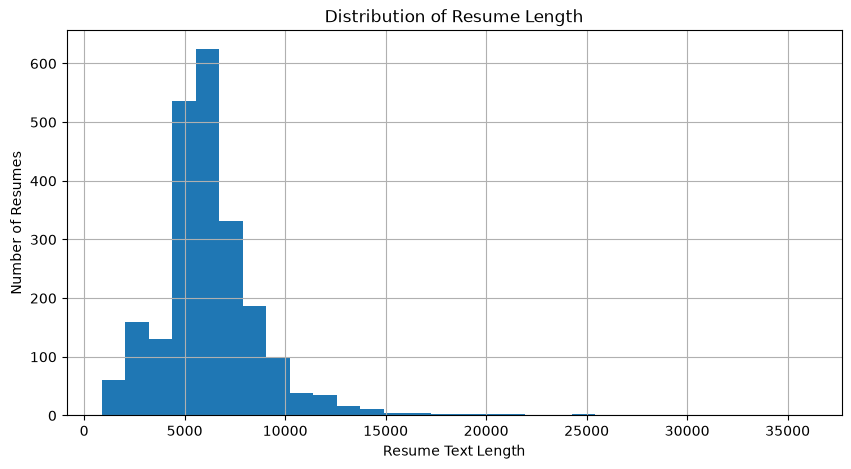

In [71]:

df['text_length'].hist(bins=30, figsize=(10, 5))

plt.xlabel('Resume Text Length')
plt.ylabel('Number of Resumes')
plt.title('Distribution of Resume Length')
plt.show()

In [72]:
df['text'].duplicated().sum()

np.int64(4)

In [73]:
df.drop_duplicates(subset=['text'], inplace= True)

In [74]:
df[df['text'].duplicated(keep=False)]

,category,skills,education,experience,text,text_length


In [75]:
df.shape

(2253, 6)

In [76]:
import re

df['clean_text'] = df['text'].apply(
    lambda x: re.sub(r'https?://\S+|www\.\S+|(?:[a-zA-Z0-9-]+\.)+(?:com|org|net|ly|gl)/\S+','',x)
)

In [77]:
print(df['clean_text'].iloc[0])

         BILINGUAL DOMESTIC VIOLENCE ADVOCATE         Skills        Word programs (including Excel and Access), EPIC and other 
electronic medical records, and the database Efforts to Outcome (ETO). Working knowledge     
of SAS and R.            Experience      Bilingual Domestic Violence Advocate     Sep 2015   to   Nov 2016      Company Name   －   City  ,   State     Provided advocacy services appropriate to client needs to a caseload of approximately 30 clients, through in person and/or phone contact.  Advocacy services included crisis intervention, risk assessment, safety planning, supportive counseling, and assistance in accessing community resources.  Covered on-call service one to two times a week, on average.  On-call service entailed serving as the first responder for intimate partner violence referrals from the hospital, as well as self-referrals from the community.  Documented in Passageway database (ETO) and EPIC as appropriate.  Utilized various clinical strategies in wor

In [78]:
df['clean_text'] = df['clean_text'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

In [79]:
print(df['clean_text'].iloc[0][:1000])

BILINGUAL DOMESTIC VIOLENCE ADVOCATE Skills Word programs (including Excel and Access), EPIC and other electronic medical records, and the database Efforts to Outcome (ETO). Working knowledge of SAS and R. Experience Bilingual Domestic Violence Advocate Sep 2015 to Nov 2016 Company Name － City , State Provided advocacy services appropriate to client needs to a caseload of approximately 30 clients, through in person and/or phone contact. Advocacy services included crisis intervention, risk assessment, safety planning, supportive counseling, and assistance in accessing community resources. Covered on-call service one to two times a week, on average. On-call service entailed serving as the first responder for intimate partner violence referrals from the hospital, as well as self-referrals from the community. Documented in Passageway database (ETO) and EPIC as appropriate. Utilized various clinical strategies in work with clients. Provided clients with psycho-educational resources regardin

In [80]:
df['clean_text'] = df['clean_text'].str.lower()

In [81]:
df['clean_text'] = df['clean_text'].apply(
    lambda x : re.sub(r'<.*?>', ' ', x)
)

In [82]:
df[['text', 'clean_text']].head(2)

,text,clean_text
0,BILINGUAL DOMESTIC VIOLENCE ADVOCATE ...,bilingual domestic violence advocate skills wo...
1,CUSTOMER SERVICE ADVOCATE Summa...,customer service advocate summary talented cus...


In [83]:
df['skills'].iloc[0]

'Word programs (including Excel and Access), EPIC and other electronic medical records, Efforts to Outcome (ETO), SAS, R, trauma, crisis intervention, risk assessment, safety planning, supportive counseling, bilingual Spanish'

In [84]:
df[['skills', 'education', 'experience']].head()

,skills,education,experience
0,"Word programs (including Excel and Access), EP...","Boston University, Master of Public Health, Ep...","Bilingual Domestic Violence Advocate, Intern, ..."
1,"Superb sales professional, Store planning and ...","William Penn Vo-tech, General-Business, High S...","Customer Service Advocate, Sales Manager, Sale..."
2,"Domestic Violence, Sexual Abuse, Rape, Prostit...","Boricua College, Human Services Psychology and...","Clinical Service Advocate, Women's Empowerment..."
3,"Accounting, Cashiering, Coaching, Computer tra...",University of Phoenix - Master of Business Adm...,"PH Inpatient/Financial Advocate Supervisor, PH..."
4,"Microsoft Suite Proficiency, RightFax Ventura,...","El Centro Community College, Health Administra...","Customer Service Advocate, Collection Speciali..."


Load 2nd dataset

In [87]:
job_df = pd.read_parquet("train-00000-of-00001.parquet")

In [88]:
job_df.shape

(1167, 5)

In [89]:
job_df.columns

Index(['job_id', 'category', 'job_title', 'job_description', 'job_skill_set'], dtype='str')

In [90]:
job_df.head()

,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"['employee relations', 'talent acquisition', '..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"['Talent Acquisition', 'Employee Performance M..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"['Human Resources Management', 'Recruitment', ..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"['talent management', 'organizational developm..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,"['Microsoft Office', 'Data analysis', 'Employe..."


In [91]:
print(job_df['job_description'].iloc[0])
print("\n--- REQUIRED SKILLS ---")
print(job_df['job_skill_set'].iloc[0])

SUMMARY
THE SR. HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTIONS INCLUDING EMPLOYEE RELATIONS, TALENT ACQUISITION, PERFORMANCE MANAGEMENT, PAYROLL, COMPENSATION AND BENEFITS. THE SR. HR GENERALIST HAS RESPONSIBILITIES THAT ARE STRATEGIC, ADMINISTRATIVE, AND CONSULTATIVE. THIS ROLE PROVIDES CONSULTATIVE HR BUSINESS PARTNER SUPPORT TO ASSIGNED BUSINESS UNITS ACROSS ALL ASPECTS OF THE EMPLOYEE LIFE CYCLE. THIS ROLE ALSO SUPPORTS HR OPERATIONS WITH WEEKLY PAYROLL PROCESSING. THE SR. HR GENERALIST IS ALSO RESPONSIBLE FOR DEVELOPING AND IMPLEMENTING HR SOLUTIONS THAT ALIGN WITH THE COMPANY'S GOALS, ENSURING A HIGH LEVEL OF EMPLOYEE ENGAGEMENT, AND FOSTERING A POSITIVE AND INCLUSIVE WORKPLACE CULTURE.
KEY RESPONSIBILITIES:
· CONSULT WITH ASSIGNED BUSINESS PARTNERS ON ALL ASPECTS OF HR. · FACILITATE AND COMMUNICATE ORGANIZATIONAL POLICIES AND PROGRAMS TO ASSIGNED BUSINESS PARTNERS AND ENSURE LABOR LAW AND REGULATORY COMPLIANCE.· PARTNER WITH BUSINESS LEADERS IN ASSIGNED AREAS TO UN

In [92]:
type(job_df['job_skill_set'].iloc[0])

str